In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [6]:
# Load the cleaned data (if needed)
df = pd.read_csv("merged_cleaned_data.csv")


Basic Info

In [7]:
print("\n--- Dataset Overview ---")
print(df.info())
print("\n--- Descriptive Statistics ---")
print(df.describe().T)


--- Dataset Overview ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 46 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   deal_id           40000 non-null  object 
 1   deal_date         40000 non-null  object 
 2   customer_id       40000 non-null  object 
 3   broker_id         40000 non-null  object 
 4   property_id       40000 non-null  object 
 5   offer_price       40000 non-null  int64  
 6   final_price       40000 non-null  float64
 7   mortgage          40000 non-null  object 
 8   loan_rate         40000 non-null  float64
 9   status            40000 non-null  object 
 10  close_date        40000 non-null  object 
 11  channel           40000 non-null  object 
 12  lead_source       40000 non-null  object 
 13  notes_freeform    40000 non-null  object 
 14  price_band        40000 non-null  object 
 15  full_name         40000 non-null  object 
 16  email         

Missing Values Overview

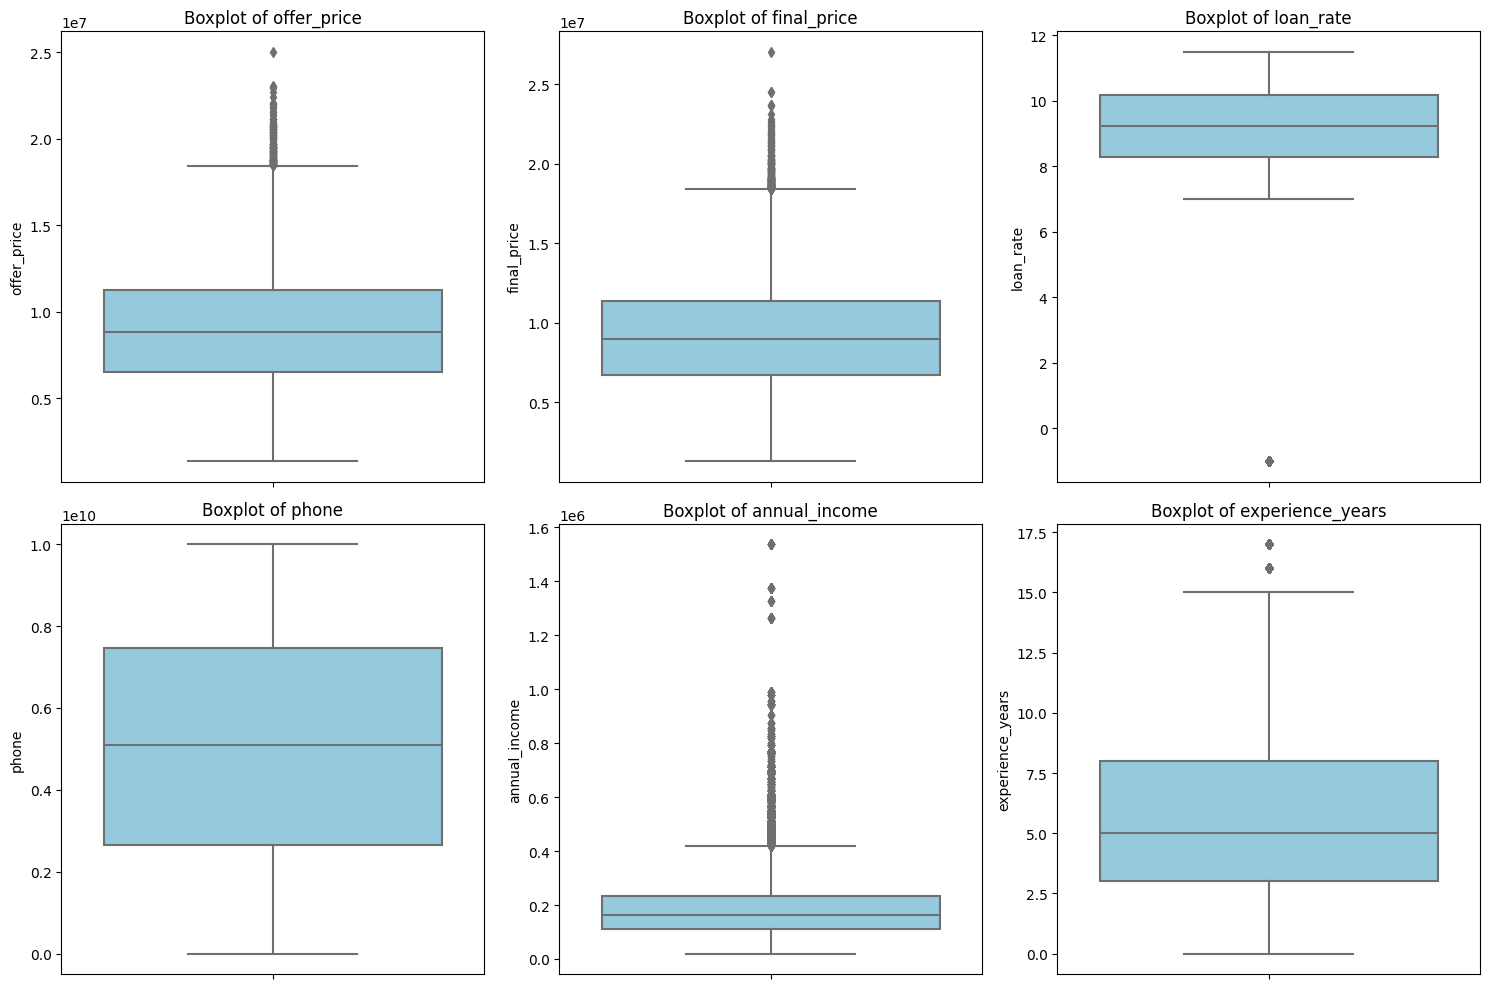

In [15]:
num_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols[:6], 1):   # show first 6 numeric features
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()



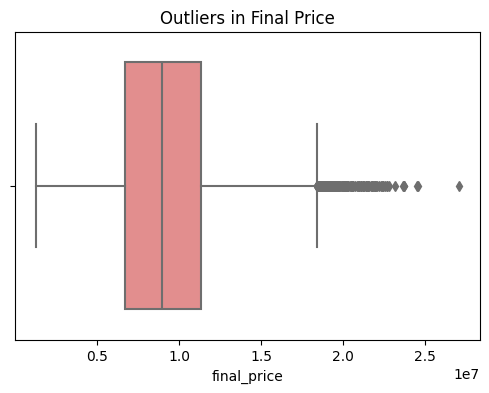

In [16]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['final_price'], color='lightcoral')
plt.title("Outliers in Final Price")
plt.show()

Statistical Outlier Detection (IQR)

In [17]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower) | (data[column] > upper)]
    return outliers, lower, upper

# Example: Detect outliers in final_price
outliers, lower, upper = detect_outliers_iqr(df, 'final_price')
print(f"💡 Detected {len(outliers)} outliers in 'final_price'")
print(f"Range: [{lower:.2f}, {upper:.2f}]")


💡 Detected 228 outliers in 'final_price'
Range: [-335100.38, 18386236.62]


Remove extreme outliers

In [18]:
df_no_outliers = df[(df['final_price'] >= lower) & (df['final_price'] <= upper)]
print("✅ Shape after removing outliers:", df_no_outliers.shape)

# ✅ Option B — Cap (Winsorize) outliers instead of removing
df_capped = df.copy()
df_capped['final_price'] = np.where(
    df_capped['final_price'] > upper, upper,
    np.where(df_capped['final_price'] < lower, lower, df_capped['final_price'])
)


✅ Shape after removing outliers: (39772, 46)


Distribution of Final Price

/usr/local/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


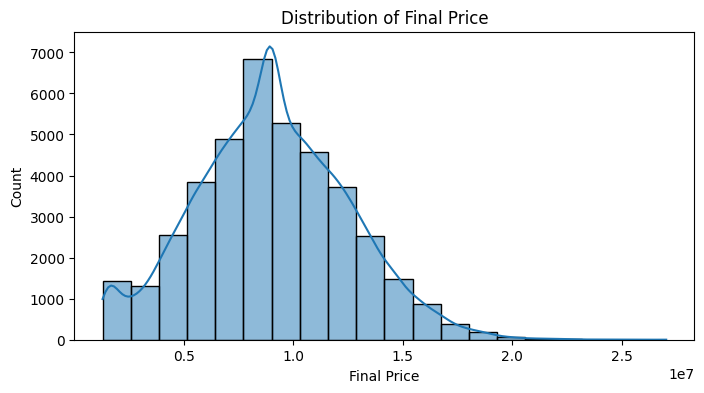

In [19]:
plt.figure(figsize=(8,4))
sns.histplot(df['final_price'], kde=True, bins=20)
plt.title("Distribution of Final Price")
plt.xlabel("Final Price")
plt.ylabel("Count")
plt.show()

Correlation Heatmap (Numerical)

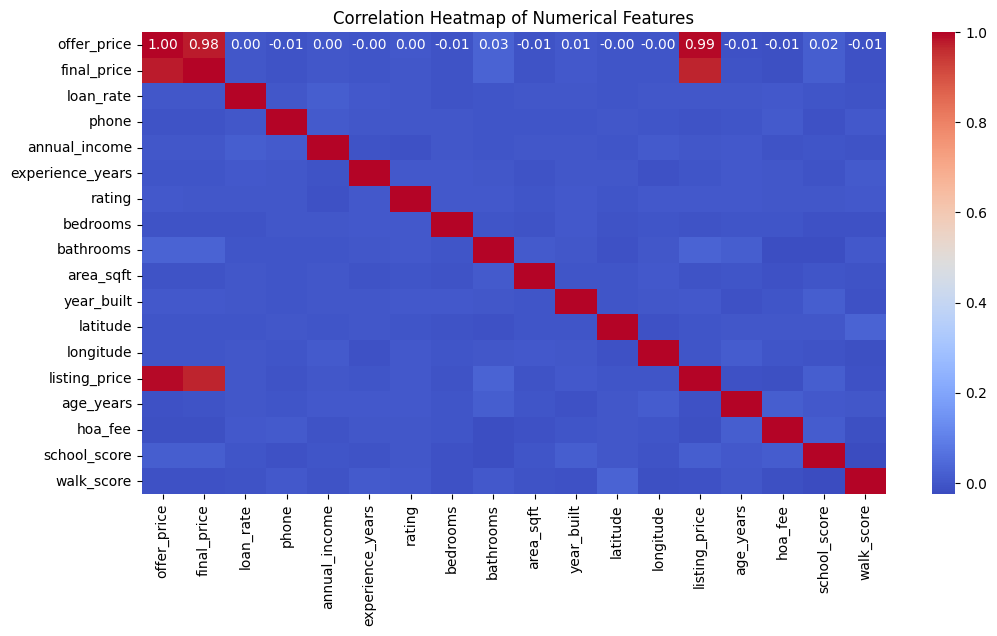

In [20]:
num_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(12,6))
sns.heatmap(num_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

City-wise Average Final Price

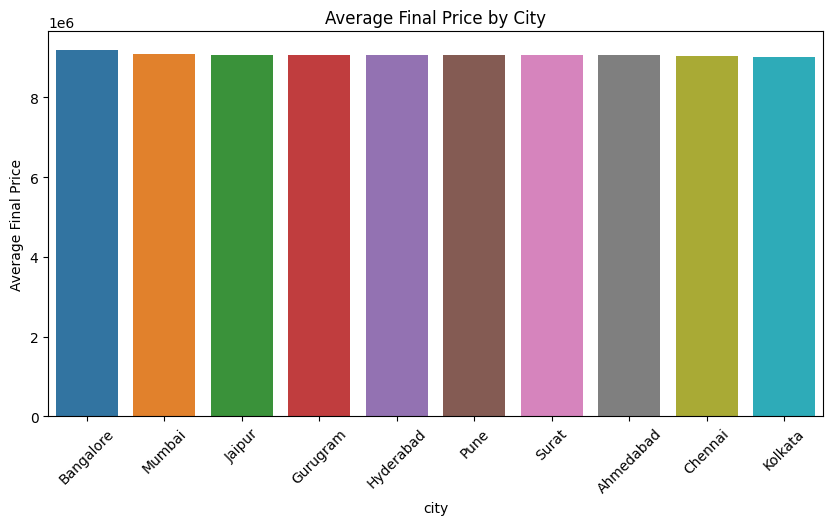

In [21]:
plt.figure(figsize=(10,5))
city_avg = df.groupby('city')['final_price'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=city_avg.index, y=city_avg.values)
plt.title("Average Final Price by City")
plt.xticks(rotation=45)
plt.ylabel("Average Final Price")
plt.show()

Bedrooms vs Final Price

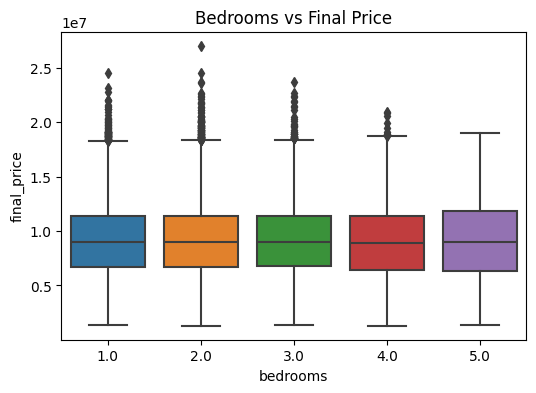

In [22]:
if 'bedrooms' in df.columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='bedrooms', y='final_price', data=df)
    plt.title("Bedrooms vs Final Price")
    plt.show()


Area (sqft) vs Final Price

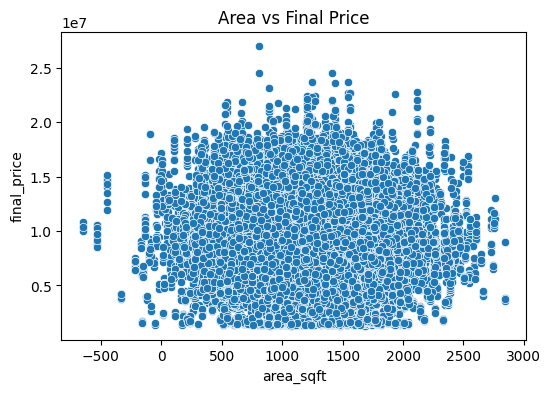

In [23]:
if 'area_sqft' in df.columns:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x='area_sqft', y='final_price', data=df)
    plt.title("Area vs Final Price")
    plt.show()